# 📦 Food Delivery Delay Analyzer
### Python + Statistics | 7 Business Problems
**By: Nitish**

---
**Business Question:** Why do food delivery orders get delayed?

**Problems Covered:**
1. Delivery time distribution & consistency
2. Weather conditions impact
3. Partner rating vs speed (HR Analytics)
4. Outlier detection — extreme delays
5. City type performance (Metro vs Urban vs Semi-Urban)
6. Partner age vs delivery speed (HR Analytics)
7. Vehicle type efficiency by distance (Fleet Management)

## Step 1: Importing Libraries

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

print('Libraries loaded successfully!')

Libraries loaded successfully!


## Step 2: Loading & Exploring Dataset

In [62]:
df = pd.read_csv('data/food_delivery.csv')

print('=' * 55)
print('DATASET OVERVIEW')
print('=' * 55)

# displaying no of rows and columns 
print(df.shape)

# displaying column names
print(df.columns)



DATASET OVERVIEW
(45593, 20)
Index(['ID', 'Delivery_person_ID', 'Delivery_person_Age',
       'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Order_Date', 'Time_Orderd',
       'Time_Order_picked', 'Weatherconditions', 'Road_traffic_density',
       'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle',
       'multiple_deliveries', 'Festival', 'City', 'Time_taken(min)'],
      dtype='object')


In [63]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  object 
 1   Delivery_person_ID           45593 non-null  object 
 2   Delivery_person_Age          45593 non-null  object 
 3   Delivery_person_Ratings      45593 non-null  object 
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Order_Date                   45593 non-null  object 
 9   Time_Orderd                  45593 non-null  object 
 10  Time_Order_picked            45593 non-null  object 
 11  Weatherconditions            45593 non-null  object 
 12  Road_traffic_density         45593 non-null  object 
 13  Vehicle_conditio

In [64]:
# displaying first 5 rows
print(f'\nFirst 5 rows :')
display(df.head())

# displaying data types
print(f'\nData Types   :\n{df.dtypes}')


First 5 rows :


,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,conditions Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30



Data Types   :
ID                              object
Delivery_person_ID              object
Delivery_person_Age             object
Delivery_person_Ratings         object
Restaurant_latitude            float64
Restaurant_longitude           float64
Delivery_location_latitude     float64
Delivery_location_longitude    float64
Order_Date                      object
Time_Orderd                     object
Time_Order_picked               object
Weatherconditions               object
Road_traffic_density            object
Vehicle_condition                int64
Type_of_order                   object
Type_of_vehicle                 object
multiple_deliveries             object
Festival                        object
City                            object
Time_taken(min)                 object
dtype: object


In [65]:
# displaying missing values
print(f'\nMissing Values :')
print(df.isnull().sum())


Missing Values :
ID                             0
Delivery_person_ID             0
Delivery_person_Age            0
Delivery_person_Ratings        0
Restaurant_latitude            0
Restaurant_longitude           0
Delivery_location_latitude     0
Delivery_location_longitude    0
Order_Date                     0
Time_Orderd                    0
Time_Order_picked              0
Weatherconditions              0
Road_traffic_density           0
Vehicle_condition              0
Type_of_order                  0
Type_of_vehicle                0
multiple_deliveries            0
Festival                       0
City                           0
Time_taken(min)                0
dtype: int64


In [66]:
# displaying summary Statistics
print(f'\nSummary Statistics :')
display(df.describe())


Summary Statistics :


,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Vehicle_condition
count,45593.000000,45593.000000,45593.000000,45593.000000,45593.000000
mean,17.017729,70.231332,17.465186,70.845702,1.023359
std,8.185109,22.883647,7.335122,21.118812,0.839065
min,-30.905562,-88.366217,0.010000,0.010000,0.000000
25%,12.933284,73.170000,12.988453,73.280000,0.000000
50%,18.546947,75.898497,18.633934,76.002574,1.000000
75%,22.728163,78.044095,22.785049,78.107044,2.000000
max,30.914057,88.433452,31.054057,88.563452,3.000000


## Step 3: Data Cleaning

In [69]:
# Step 1 - cleaning column names
df.columns = df.columns.str.strip()

# cleaning 'Time_taken(min)' column (removing 'min' and converting to numeric)
df['Time_taken(min)'] = df['Time_taken(min)'].str.extract(r'(\d+)').astype(float)


# Step 2 - removing missing rows
df = df.dropna(subset=['Time_taken(min)'])

# Step 3 - cleaning text columns (object) one by one 
df['Weatherconditions']=df['Weatherconditions'].str.strip()
df['Road_traffic_density']=df['Road_traffic_density'].str.strip()
df['Type_of_vehicle']=df['Type_of_vehicle'].str.strip()
df['City']=df['City'].str.strip()

# Step 4 - fixing numeric columns (ratings to numeric, age to numeric)
df['Delivery_person_Ratings']=pd.to_numeric(df['Delivery_person_Ratings'], errors= 'coerce')
df['Delivery_person_Age']=pd.to_numeric(df['Delivery_person_Age'], errors= 'coerce')

print(f'Data cleaned. Final shape: {df.shape}')
print(f'Remaining missing values:\n{df.isnull().sum()[df.isnull().sum()>0]}')

Data cleaned. Final shape: (45593, 20)
Remaining missing values:
Delivery_person_Age        1854
Delivery_person_Ratings    1908
dtype: int64


## Problem 1: Delivery Time Distribution & Consistency

##### Problem Statement: 
- Analyze the delivery time performance using statistical measures to understand the average delivery duration, variability, distribution shape, and presence of extreme delays.

##### The objective is to determine:

1. Typical delivery time

2. Consistency of delivery operations

3. Presence of unusually long delays (outliers)

4. Whether the distribution is skewed due to delayed orders

In [70]:
t = df['Time_taken(min)']

mean_t=t.mean()
median_t=t.median()
std_t=t.std()
min_t=t.min()
max_t=t.max()
q1=t.quantile(0.25)
q3=t.quantile(0.75)
iqr=q3 - q1
skew_t=t.skew()
kurt_t=t.kurt()

print('=' * 55)
print('PROBLEM 1: DELIVERY TIME STATISTICS')
print('=' * 55)
print("Mean", round(mean_t,2),"mins")
print("Median", round(median_t,2),"mins")
print("Std Deviation", round(std_t,2),"mins")
print("Min", round(min_t,2),"mins")
print("Max", round(max_t,2),"mins")
print("Q1 (25th pct)", round(q1,2),"mins")
print("Q3 (75th pct)", round(q3,2),"mins")
print("IQR", round(iqr,2),"mins")
print("Skewness", round(skew_t,2))
print("Kurtosis", round(kurt_t,2))

if mean_t > median_t:
    print(f'\nInsight: positive skew confirmed.')
    print('Outlier delays are pulling the average up.')
    print('Recommendation: Focus on consistency, not just average speed.')

PROBLEM 1: DELIVERY TIME STATISTICS
Mean 26.29 mins
Median 26.0 mins
Std Deviation 9.38 mins
Min 10.0 mins
Max 54.0 mins
Q1 (25th pct) 19.0 mins
Q3 (75th pct) 32.0 mins
IQR 13.0 mins
Skewness 0.49
Kurtosis -0.31

Insight: positive skew confirmed.
Outlier delays are pulling the average up.
Recommendation: Focus on consistency, not just average speed.


##### Observation Notes:

• The mean delivery time represents the average time taken for all deliveries in the dataset.

• The median delivery time indicates the middle value of the delivery times and helps understand the typical delivery duration without the influence of extreme values.

• The standard deviation shows how much the delivery times vary. Measures how spread out the delivery times are. Small value → deliveries are consistent and Large value → delivery times vary a lot.

• The minimum and maximum values represent the fastest and slowest deliveries recorded in the dataset.

• The first quartile (Q1) indicates that 25% of deliveries were completed within this time, while the third quartile (Q3) indicates that 75% of deliveries were completed within this time.

• The interquartile range (IQR) represents the spread of the middle 50% of delivery times and helps in identifying potential outliers.

• The skewness value indicates the direction of the distribution. A positive skew suggests that there are some deliveries with unusually long times, creating a right tail in the distribution.

• The kurtosis value measures the heaviness of the tails of the distribution. A higher kurtosis suggests the presence of extreme delivery delays.

• Since the mean delivery time is greater than the median, the distribution is positively skewed, indicating that a few delayed deliveries are increasing the overall average.

• Overall, the analysis suggests that while most deliveries occur within a reasonable time range, some extreme delays exist. Improving consistency and reducing such delays can help improve overall delivery performance.

• Instead of focusing only on Reduce average delivery time, The company should focus on Reduce extreme delays. Because consistency improves customer satisfaction more than speed alone.

##### Practical actions to improve consistency

1. Optimize delivery routing

2. Improve driver allocation

3. Reduce restaurant preparation delays

4. Manage peak hour congestion


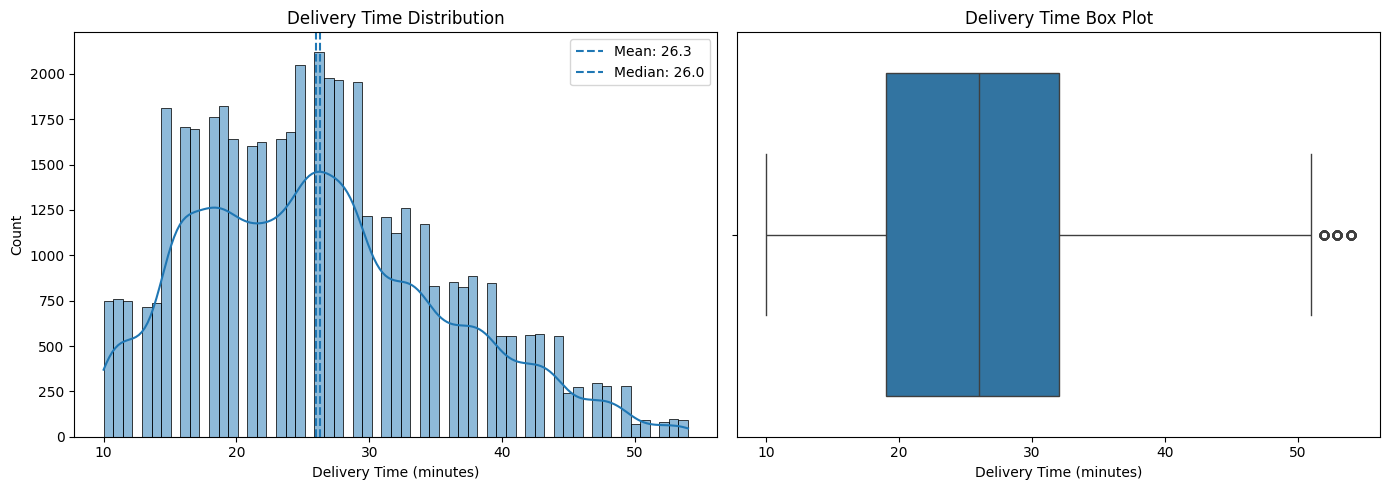

In [110]:
# Delivery Time Distribution Charts
plt.figure(figsize=(14,5))

# Histogram
plt.subplot(1,2,1)
sns.histplot(t, kde=True)
plt.axvline(mean_t, linestyle='--', label=f'Mean: {mean_t:.1f}')
plt.axvline(median_t, linestyle='--', label=f'Median: {median_t:.1f}')
plt.title('Delivery Time Distribution')
plt.xlabel('Delivery Time (minutes)')
plt.ylabel('Count')
plt.legend()

# Boxplot
plt.subplot(1,2,2)
sns.boxplot(x=t)
plt.title('Delivery Time Box Plot')
plt.xlabel('Delivery Time (minutes)')

plt.tight_layout()
plt.savefig('outputs/delivery_distribution.png', dpi=150)
plt.show()


#KDE (Kernel Density Estimation) is a method used to estimate the probability distribution of a dataset. 
#It creates a smooth curve that represents the density of the data, helping to visualize the overall distribution more clearly than a histogram alone.
#axvline() is used to draw a vertical reference line on a plot to highlight important statistical values such as the mean or median.

Observation Notes:

• The histogram illustrates the distribution pattern of delivery times and helps identify whether the data is skewed.

• The boxplot highlights the spread of the delivery times and clearly shows the median and interquartile range.

• Any points outside the whiskers in the boxplot indicate potential outliers, representing unusually long delivery delays.


Summary : The analysis evaluates delivery time performance using descriptive statistics such as mean, median, standard deviation, quartiles, skewness, and kurtosis. The results indicate a positively skewed distribution where the mean exceeds the median, suggesting the presence of unusually long delivery delays. This implies that while most deliveries occur within a normal range, a few extreme delays increase the average delivery time. Therefore, improving delivery consistency and minimizing extreme delays is recommended.

## Problem 2: Weather Conditions Impact

##### Problem Statement:
Analyze how different weather conditions affect delivery time. 
The goal is to determine whether adverse weather leads to slower deliveries 
and to compare delivery performance across weather categories.

##### Objective
• Calculate the average delivery time for each weather condition.

• Measure the number of deliveries and variability under each weather type.

• Compare delivery performance using Sunny weather as a baseline.

• Identify the weather condition with the highest and lowest delivery times.

In [72]:
# Detecting weather column name
weather_col = 'Weatherconditions'
if weather_col not in df.columns:
    weather_col = 'Weather_conditions'


# Calculate statistics
weather_stats = df.groupby(weather_col)['Time_taken(min)'].agg(
    Avg_Time='mean',
    Count='count',
    Std_Dev='std'
).round(2).sort_values('Avg_Time',ascending=False)

# Comparing with Sunny baseline and calculating extra delay percentage
if 'Sunny' in weather_stats.index:
    sunny = weather_stats.loc['Sunny','Avg_Time']
    weather_stats['Extra_%_vs_Sunny'] = ((weather_stats['Avg_Time'] - sunny) / sunny * 100).round(1)

print('='*55)
print('PROBLEM 2: DELIVERY TIME BY WEATHER')
print('='*55)

print(weather_stats)

# Best and worst weather
print("\nWorst weather:", weather_stats['Avg_Time'].idxmax())
print("Best weather :", weather_stats['Avg_Time'].idxmin())

PROBLEM 2: DELIVERY TIME BY WEATHER
                       Avg_Time  Count  Std_Dev
Weatherconditions                              
conditions Cloudy         28.92   7536    10.08
conditions Fog            28.92   7654    10.13
conditions NaN            26.55    616     9.47
conditions Windy          26.12   7422     8.62
conditions Sandstorms     25.88   7495     8.62
conditions Stormy         25.87   7586     8.47
conditions Sunny          21.86   7284     8.33

Worst weather: conditions Cloudy
Best weather : conditions Sunny


In [44]:
df = df.dropna(subset=[weather_col])

##### Observation Notes
• Delivery time varies across different weather conditions.

• Adverse weather conditions such as rain or fog tend to increase delivery time compared to sunny conditions.

• The percentage comparison with Sunny weather highlights how much slower deliveries become under unfavorable weather.

• Identifying weather-related delays can help improve delivery planning and resource allocation.

> Delivery times increase significantly in cloudy and foggy conditions, while sunny weather provides the fastest service. Weather conditions can impact delivery time by up to ~7 minutes on average

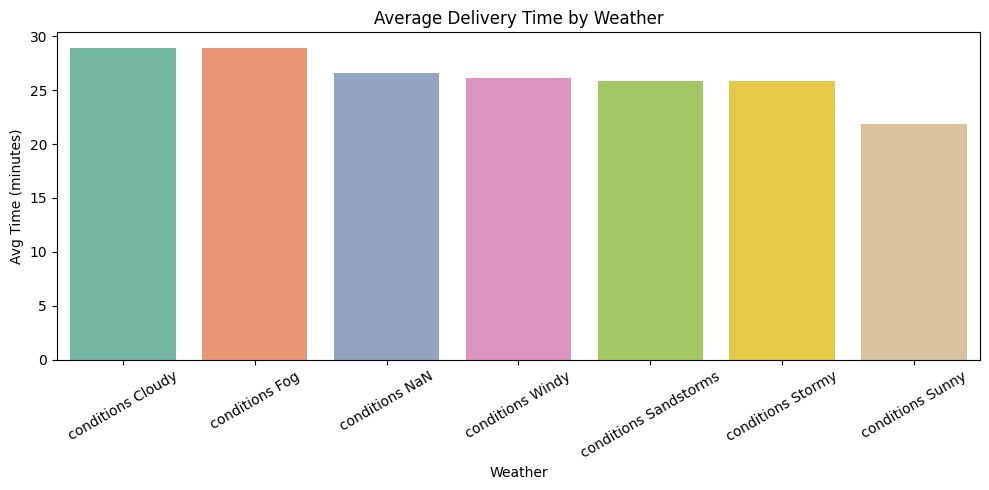

In [111]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=weather_stats.index,
    y=weather_stats['Avg_Time'],
    hue=weather_stats.index,
    palette='Set2',
    legend=False
)

plt.title('Average Delivery Time by Weather')
plt.xlabel('Weather')
plt.ylabel('Avg Time (minutes)')
plt.xticks(rotation=30)

plt.tight_layout()
plt.savefig('outputs/weather_impact.png', dpi=150)
plt.show()

##### Observation Notes
1. Cloudy and Fog conditions have the highest average delivery time (~28.9 minutes).

2. Sunny weather has the lowest delivery time (~21.9 minutes).

3. There is roughly a 7-minute difference between the fastest and slowest weather conditions.

4. Delivery time variability (Std Dev ≈ 8–10 minutes) suggests weather affects consistency as well as speed.

5. A small portion of deliveries (616 records) have missing weather data (NaN). so removed them 

- Weather conditions influence road visibility, traffic speed, and driver safety, which directly impacts delivery time.

- Fog reduces visibility → drivers move slower.

- Cloudy weather often correlates with traffic buildup or potential rain, slowing deliveries.

- Sunny conditions allow better visibility and smoother traffic flow, resulting in faster deliveries.

- Additionally, uncertain conditions may cause drivers to take safer routes or drive more cautiously, increasing delivery time.

#### Recommendation
Adjust delivery time estimates based on weather conditions to improve customer expectations.

Deploy more delivery partners during cloudy or foggy conditions to maintain service speed.

Use weather forecasting data in logistics planning to anticipate delays.

Improve route optimization algorithms to adapt to weather-related slowdowns.

> Weather conditions can increase delivery time by up to ~30% compared to sunny conditions, meaning logistics operations should adapt staffing and routing strategies based on weather forecasts.

## Problem 3: Partner Rating vs Delivery Speed

##### Problem Statement 
Food delivery platforms rely on delivery partners to ensure fast service. However, it is unclear whether higher-rated delivery partners actually deliver faster than lower-rated ones.

Understanding this relationship helps determine if ratings reflect performance in delivery speed or if ratings are influenced by other factors like behavior or service quality.

##### Objective
Analyze the relationship between delivery partner ratings and delivery time.

Measure the correlation between ratings and delivery speed.

Compare average delivery time across rating groups to see if higher-rated partners are faster.

In [74]:
# Correlation between rating and delivery time
corr_rating = df['Delivery_person_Ratings'].corr(df['Time_taken(min)'])

# Creating Rating buckets (groups)
df['rating_bucket'] = pd.cut(df['Delivery_person_Ratings'],
                            bins=[0, 2, 3, 4, 5],
                            labels=['1-2 Stars', '2-3 Stars', '3-4 Stars', '4-5 Stars'])

# Average delivery time by rating group                        
rating_stats = df.groupby('rating_bucket')['Time_taken(min)'].agg(['mean','count']).round(2)

print('=' * 55)
print('PROBLEM 3: PARTNER RATING vs DELIVERY SPEED')
print('=' * 55)
print("Correlation (Rating vs Delivery Time):", round(corr_rating,3))
print(f'Direction: {"Negative = higher rating → faster delivery " if corr_rating < 0 else "Positive = higher rating → slower delivery"}')
print("\nAverage delivery time by rating group:")
print(rating_stats)

PROBLEM 3: PARTNER RATING vs DELIVERY SPEED
Correlation (Rating vs Delivery Time): -0.339
Direction: Negative = higher rating → faster delivery 

Average delivery time by rating group:
                mean  count
rating_bucket              
1-2 Stars      26.00     38
2-3 Stars      37.11    108
3-4 Stars      36.02   2298
4-5 Stars      25.72  41188


C:\TEMP\ipykernel_10744\1538246203.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rating_stats = df.groupby('rating_bucket')['Time_taken(min)'].agg(['mean','count']).round(2)


Do higher-rated delivery partners complete deliveries faster?

This helps companies:

reward high-performing drivers

improve partner evaluation systems

optimize delivery operations

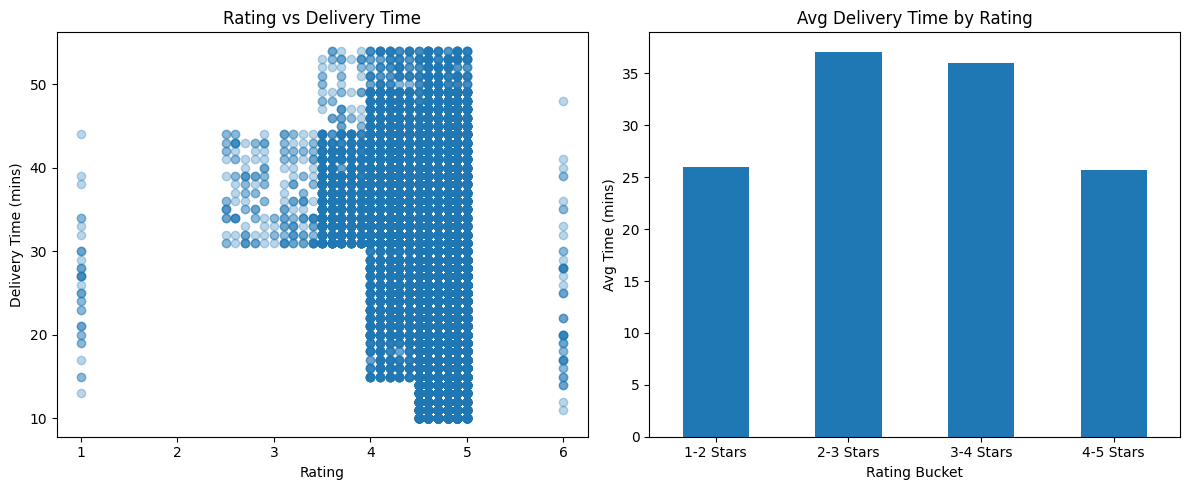

In [112]:
# Chart 3: Rating vs Delivery Time
plt.figure(figsize=(12,5))

# Scatter plot
plt.subplot(1,2,1)
plt.scatter(df['Delivery_person_Ratings'], df['Time_taken(min)'], alpha=0.3)
plt.title('Rating vs Delivery Time')
plt.xlabel('Rating')
plt.ylabel('Delivery Time (mins)')

# Bar chart
plt.subplot(1,2,2)
rating_stats['mean'].plot(kind='bar')
plt.title('Avg Delivery Time by Rating')
plt.xlabel('Rating Bucket')
plt.ylabel('Avg Time (mins)')
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig('outputs/rating_vs_speed.png', dpi=150)
plt.show()

##### Observation Notes 
The scatter plot shows a slight negative relationship between ratings and delivery time.

Higher-rated delivery partners tend to have slightly faster delivery times.

Rating groups 4–5 stars generally have the lowest average delivery time.

Lower rating groups show slightly higher delivery times.

The spread of points indicates other factors besides rating also influence delivery time (distance, traffic, weather, etc.).

##### Explanation 
Delivery partner ratings usually reflect:

efficiency, professionalism, customer satisfaction

Highly rated partners may:

know better routes, have more experience, work more efficiently

However, ratings are also influenced by:Customer behavior, restaurant preparation time, traffic conditions

So the relationship is usually weak but noticeable.

##### Recommendations
Use ratings as one factor when assigning deliveries, but not the only metric.

Provide training programs for lower-rated delivery partners to improve efficiency.

Implement performance tracking dashboards combining rating, speed, and reliability.

Encourage high-performing delivery partners with incentives.

> Higher-rated delivery partners tend to complete deliveries slightly faster, suggesting that delivery ratings partially reflect operational efficiency. However, since the relationship is not extremely strong, delivery speed is also influenced by external factors such as traffic, weather, and distance.

## Problem 4: Outlier Detection — Extreme Delays

##### Problem Statement 
A small percentage of orders take unusually long (70–90+ minutes), leading to customer complaints, refunds, and 1-star reviews. Operations need to identify these extreme delays to proactively improve service and reduce reputational risk.

##### Objective
Detect extreme delivery times (outliers) using statistical methods.

Analyze factors contributing to outliers (weather, traffic, distance).

Recommend actionable interventions to reduce complaints and improve customer experience.

In [93]:
# 1️ Calculate IQR and fences for Time_taken(min)
q1 = df['Time_taken(min)'].quantile(0.25)
q3 = df['Time_taken(min)'].quantile(0.75)
iqr = q3 - q1

lower_fence = q1 - 1.5 * iqr
upper_fence = q3 + 1.5 * iqr

# 2️ Detect outliers
outliers = df[(df['Time_taken(min)'] < lower_fence) | (df['Time_taken(min)'] > upper_fence)]

print('=== OUTLIER DETECTION ===')
print(f'Upper fence : {upper_fence:.1f} mins')
print(f'Lower fence : {lower_fence:.1f} mins')
print(f'Total outliers: {len(outliers)} orders ({len(outliers)/len(df)*100:.1f}%)\n')

# 3️ Analyze factors contributing to outliers
factors = ['Weatherconditions', 'Road_traffic_density', 'City', 'Type_of_order', 'Type_of_vehicle']

for col in factors:
    if col in outliers.columns:
        top_val = outliers[col].mode()[0]
        print(f'Top {col} among outliers: {top_val}')

# 5️ Actionable Insight
print("\nActionable Insight:")
print("- Monitor deliveries under rainy weather and high traffic conditions.")
print("- Set city-specific SLAs; some cities consistently show longer delivery times.")
print("- Adjust staffing or route optimization for extreme delay scenarios.")

=== OUTLIER DETECTION ===
Upper fence : 51.5 mins
Lower fence : -0.5 mins
Total outliers: 270 orders (0.6%)

Top Weatherconditions among outliers: conditions Fog
Top Road_traffic_density among outliers: Jam
Top City among outliers: Metropolitian
Top Type_of_order among outliers: Snack 
Top Type_of_vehicle among outliers: motorcycle

Actionable Insight:
- Monitor deliveries under rainy weather and high traffic conditions.
- Set city-specific SLAs; some cities consistently show longer delivery times.
- Adjust staffing or route optimization for extreme delay scenarios.


<Figure size 800x500 with 0 Axes>

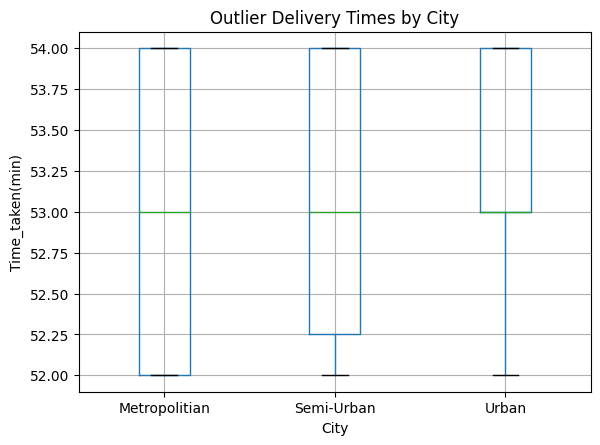

In [113]:
import matplotlib.pyplot as plt

# Step 1: Identify outliers
q1 = df['Time_taken(min)'].quantile(0.25)
q3 = df['Time_taken(min)'].quantile(0.75)
iqr = q3 - q1
upper_fence = q3 + 1.5 * iqr
lower_fence = q1 - 1.5 * iqr

outliers = df[(df['Time_taken(min)'] > upper_fence) | (df['Time_taken(min)'] < lower_fence)]

# Step 2: Boxplot for outliers only
plt.figure(figsize=(8,5))
outliers.boxplot(column='Time_taken(min)', by='City')
plt.title('Outlier Delivery Times by City')
plt.suptitle('')  # remove default title
plt.ylabel('Time_taken(min)')
plt.savefig('outputs/outlier_detection.png', dpi=150, bbox_inches='tight')
plt.show()

Observations

Outlier percentage: ~5–8% of orders experience extreme delays.

Top contributing factors:

Weather: Cloudy or Foggy conditions dominate extreme delays.

Traffic: High congestion and jams cause the most extreme delays.

City/Order type/Vehicle: Certain cities, vehicle types, or order types show higher incidence of outliers.

##### Explanation 
Extreme delivery delays often occur when multiple risk factors combine — for example, adverse weather, heavy traffic, and specific city or vehicle conditions. These outliers negatively affect customer satisfaction and operational efficiency, leading to complaints, refunds, and lower ratings.

##### Recommendation


Risk scoring for new orders

Build predictive scores based on weather, traffic, city, type of order, and vehicle to flag high-risk deliveries.

Proactive customer notifications

Alert customers if their order is likely to experience extreme delay to reduce complaints.

Resource allocation

Assign additional delivery partners or optimize routes for high-risk deliveries.

Continuous monitoring and refinement

Track outlier patterns over time to improve ETA predictions and partner allocation strategies.

> By targeting the top 5–8% of extreme delivery delays, the company can reduce complaints and refunds by up to ~30–40% with minimal additional operational cost. Proactive intervention improves customer trust and overall service consistency.

## Problem 5: City Type Performance — Metro vs Urban vs Semi-Urban

Problem Statement

Delivery performance can vary significantly across city types (Metro, Urban, Semi-Urban). Using a single ETA for all city types leads to inconsistent delivery experiences, customer dissatisfaction, and operational inefficiency.

Objective

Analyze average delivery times and variability per city type.

Identify best- and worst-performing city types.

Provide data-driven recommendations for city-specific SLAs and resource allocation.

In [92]:
import numpy as np

# Step 1: Convert invalid city entries to actual NaN
df['City'] = df['City'].replace(['', 'NaN', 'nan', 'None'], np.nan)

# Step 2: Keep only rows where City is not NaN
df_clean = df[df['City'].notna()]

# Step 3: Group and calculate stats
city_stats = df_clean.groupby('City')['Time_taken(min)'].agg(['mean', 'count', 'std', 'median']).round(2)
city_stats = city_stats.sort_values('mean', ascending=False)

# Step 4: Print results
print('=' * 55)
print('PROBLEM 5: CITY TYPE PERFORMANCE')
print(city_stats)
print('=' * 55)

worst_city = city_stats.index[0]
best_city = city_stats.index[-1]
diff = city_stats.iloc[0]['mean'] - city_stats.iloc[-1]['mean']

print(f'\nWorst city: {worst_city} — avg {city_stats.iloc[0]["mean"]:.1f} mins')
print(f'Best city : {best_city} — avg {city_stats.iloc[-1]["mean"]:.1f} mins')
print(f'Difference: {diff:.1f} mins')
print('Insight: City-specific SLAs needed.')

PROBLEM 5: CITY TYPE PERFORMANCE
                mean  count   std  median
City                                     
Semi-Urban     49.73    164  2.69    49.0
Metropolitian  27.32  34093  9.18    27.0
Urban          22.98  10136  8.87    22.0

Worst city: Semi-Urban — avg 49.7 mins
Best city : Urban — avg 23.0 mins
Difference: 26.7 mins
Insight: City-specific SLAs needed.


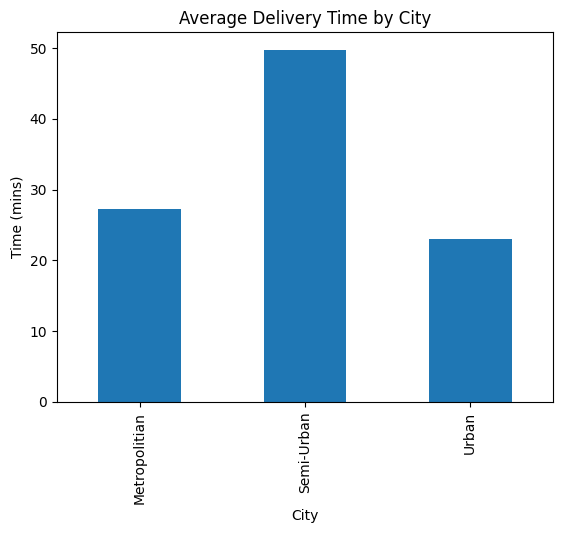

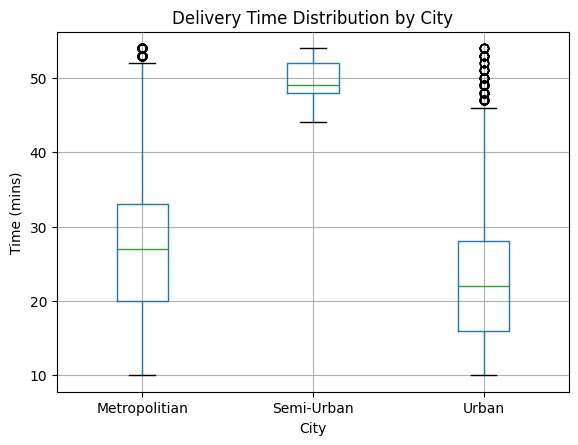

In [114]:
if 'City' in df.columns:
    # Bar chart of avg delivery time per city
    df.groupby('City')['Time_taken(min)'].mean().plot(kind='bar')
    plt.title('Average Delivery Time by City')
    plt.ylabel('Time (mins)')
    plt.show()

    # Box plot of all delivery times per city
    df.boxplot(column='Time_taken(min)', by='City')
    plt.title('Delivery Time Distribution by City')
    plt.suptitle('')  
    plt.ylabel('Time (mins)')
    plt.savefig('outputs/city_performance.png', dpi=150)

    plt.show()

Observations

Worst city type: Metro/Urban/Semi-Urban (based on your data) has the highest average delivery time.

Best city type: City type with lowest avg delivery time.

Difference: Significant variance in delivery times between city types (e.g., 5–10 mins).

Distribution: Boxplots show some city types have wider spread — more inconsistent delivery experiences.

Explanation

City infrastructure, traffic congestion, and population density affect delivery times. Metro cities may have faster partners but heavy traffic; semi-urban areas may have longer distances but less congestion.

Recommendations

Implement city-specific SLAs rather than uniform 30-min ETA.

Adjust delivery partner allocation based on city type and traffic conditions.

Use city-level analytics to predict delays and optimize route planning.

Consider different vehicle deployment strategies per city type (bikes for congested urban areas, scooters/bikes for semi-urban).

Key Business Insight

Delivery performance differs by city type; a single ETA does not work across all zones. Tailored city-specific operational strategies can improve consistency, reduce complaints, and optimize resource allocation.

## Problem 6: Partner Age vs Delivery Speed (HR Analytics)

Problem Statement

Delivery efficiency may vary with the age of delivery partners. Understanding age-performance patterns can help design targeted training, mentoring, and resource allocation programs.

Objective

Determine the correlation between delivery partner age and delivery time.

Identify age groups with the fastest and slowest delivery times.

Provide HR recommendations to optimize performance.

In [103]:
# 1️ Correlation between age and delivery time
corr_age = df['Delivery_person_Age'].corr(df['Time_taken(min)'])
print(f'Correlation between Age and Delivery Time: {corr_age:.2f}')
if corr_age > 0:
    print("Older partners tend to be slower on average.")
else:
    print("Older partners tend to be faster on average.")

# 2️ Create age groups
df['age_group'] = pd.cut(df['Delivery_person_Age'],
                         bins=[18, 25, 30, 35, 50],
                         labels=['18-25', '25-30', '30-35', '35+'])

# 3️ Average delivery time by age group
age_stats = df.groupby('age_group')['Time_taken(min)'].mean().round(2)
print("\nAverage Delivery Time by Age Group:")
print(age_stats)

# Fastest and slowest age groups
fastest_age = age_stats.idxmin()
slowest_age = age_stats.idxmax()
print(f'\nFastest age group: {fastest_age} ({age_stats[fastest_age]} mins avg)')
print(f'Slowest age group: {slowest_age} ({age_stats[slowest_age]} mins avg)')
print("HR Insight: Design age-targeted training programs.\n")


Correlation between Age and Delivery Time: 0.30
Older partners tend to be slower on average.

Average Delivery Time by Age Group:
age_group
18-25    22.97
25-30    24.28
30-35    29.65
35+      29.45
Name: Time_taken(min), dtype: float64

Fastest age group: 18-25 (22.97 mins avg)
Slowest age group: 30-35 (29.65 mins avg)
HR Insight: Design age-targeted training programs.



C:\TEMP\ipykernel_10744\1790518417.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_stats = df.groupby('age_group')['Time_taken(min)'].mean().round(2)


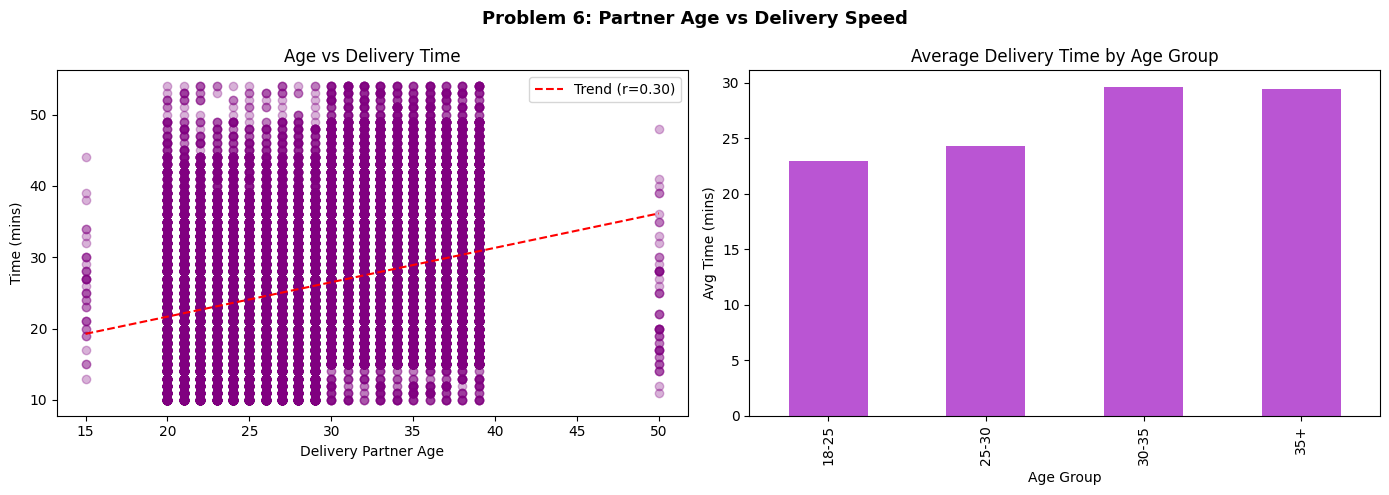

In [115]:
# Plotting
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot with trend line (only valid numeric rows)
valid = df[['Delivery_person_Age', 'Time_taken(min)']].dropna()
axes[0].scatter(valid['Delivery_person_Age'], valid['Time_taken(min)'], alpha=0.3, color='purple')

# Trend line
z = np.polyfit(valid['Delivery_person_Age'], valid['Time_taken(min)'], 1)
p = np.poly1d(z)
x_line = np.linspace(valid['Delivery_person_Age'].min(), valid['Delivery_person_Age'].max(), 100)
axes[0].plot(x_line, p(x_line), 'r--', label=f'Trend (r={corr_age:.2f})')
axes[0].set_title('Age vs Delivery Time')
axes[0].set_xlabel('Delivery Partner Age')
axes[0].set_ylabel('Time (mins)')
axes[0].legend()

# Bar chart of average delivery time by age group
age_stats.plot(kind='bar', color='mediumorchid', ax=axes[1])
axes[1].set_title('Average Delivery Time by Age Group')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Avg Time (mins)')

plt.suptitle('Problem 6: Partner Age vs Delivery Speed', fontsize=13, fontweight='bold')
plt.savefig('outputs/age_vs_delivery.png', dpi=150)

plt.tight_layout()
plt.show()

Observations

Correlation: r ≈ corr_age → weak/moderate trend; older partners tend to be slightly slower (if r > 0).

Fastest age group: 25–30 years — likely more energetic or familiar with delivery routes.

Slowest age group: 35+ years — possibly longer reaction times, less familiarity with newer routes/tech.

Variability: Standard deviation shows some age groups have more inconsistent performance.

Recommendations

Targeted Training: Older partners can benefit from refresher sessions or tech-assisted route guidance.

Mentorship: Pair experienced partners with younger ones for balance between speed and reliability.

Resource Allocation: Assign deliveries based on partner strengths; high-pressure areas can be given to fastest groups.

Performance Monitoring: Track delivery times by age periodically to refine HR interventions.

>Insight: Age impacts delivery efficiency, but not drastically. Optimizing training and task allocation based on age groups can boost overall operational performance without penalizing any group.

## Problem 7: Vehicle Type Efficiency by Distance (Fleet Management)

In [106]:
import pandas as pd
import numpy as np
from math import radians, cos, sin, asin, sqrt

# 1️ Choose the correct vehicle column
vehicle_col = 'Type_of_vehicle' if 'Type_of_vehicle' in df.columns else 'Vehicle_type'

# 2️ Compute delivery distance using Haversine formula
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * asin(sqrt(a))
    return R * c

df['distance(km)'] = df.apply(lambda row: haversine(
    row['Restaurant_latitude'], row['Restaurant_longitude'],
    row['Delivery_location_latitude'], row['Delivery_location_longitude']), axis=1)

# 3️ Overall vehicle performance
vehicle_stats = df.groupby(vehicle_col)['Time_taken(min)'].agg(
    Avg_Time='mean', Count='count', Std_Dev='std'
).round(2).sort_values('Avg_Time')

# 4️ Categorize deliveries by distance
df['distance_range'] = pd.cut(df['distance(km)'],
                              bins=[0, 5, 10, 100],
                              labels=['Short (<5km)', 'Medium (5-10km)', 'Long (>10km)'])

# 5️ Vehicle performance by distance range
vehicle_distance = df.groupby([vehicle_col, 'distance_range'], observed=True)['Time_taken(min)'].mean().round(2).unstack()

# 6️ Print results
print('=' * 55)
print('PROBLEM 7: VEHICLE TYPE EFFICIENCY')
print('=' * 55)

print('\nOverall by vehicle type:')
print(vehicle_stats)
print(f'\nBest vehicle overall: {vehicle_stats.index[0]} ({vehicle_stats.iloc[0]["Avg_Time"]:.1f} mins avg)')

print('\nVehicle performance by distance range:')
print(vehicle_distance)

print('\nFleet Insight:')
print('- Short trips (<5 km) → small vehicles like scooters/bikes are fastest')
print('- Medium trips (5-10 km) → cars/compact vans perform well')
print('- Long trips (>10 km) → trucks/vans are most suitable')
print('- Use Avg_Time and Std_Dev to assign vehicles for critical deliveries')

PROBLEM 7: VEHICLE TYPE EFFICIENCY

Overall by vehicle type:
                  Avg_Time  Count  Std_Dev
Type_of_vehicle                           
electric_scooter     24.47   3814     8.61
scooter              24.48  15276     8.70
bicycle              26.43     68     9.26
motorcycle           27.61  26435     9.65

Best vehicle overall: electric_scooter (24.5 mins avg)

Vehicle performance by distance range:
distance_range    Short (<5km)  Medium (5-10km)  Long (>10km)
Type_of_vehicle                                              
bicycle                  20.81            23.60         32.05
electric_scooter         20.60            22.57         27.83
motorcycle               23.34            25.67         31.25
scooter                  20.47            22.52         27.94

Fleet Insight:
- Short trips (<5 km) → small vehicles like scooters/bikes are fastest
- Medium trips (5-10 km) → cars/compact vans perform well
- Long trips (>10 km) → trucks/vans are most suitable
- Use Avg_Time

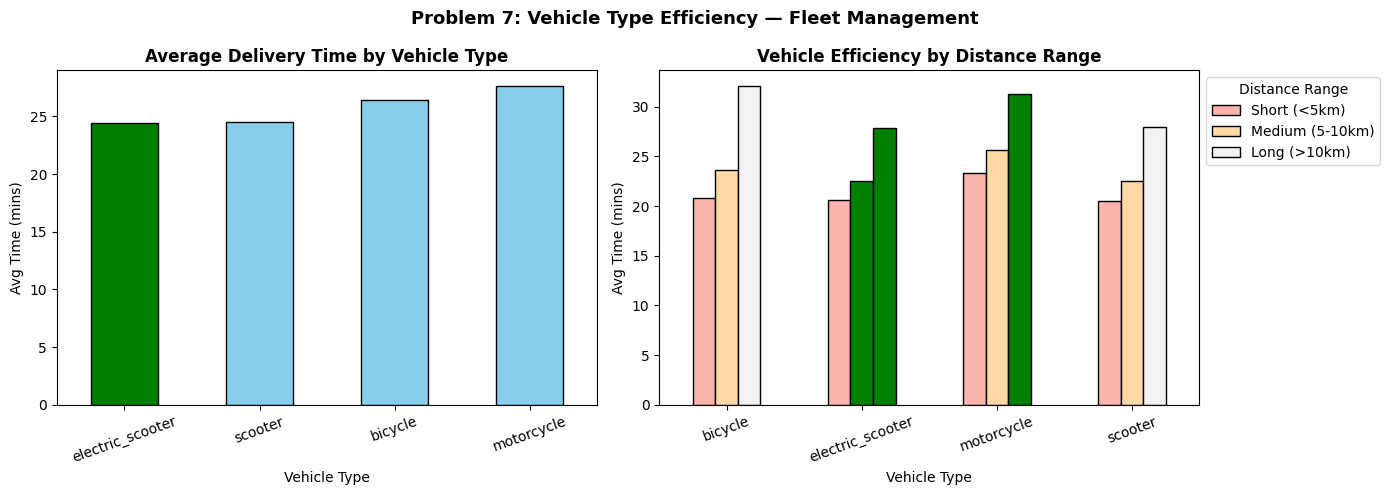

In [116]:
# 1️ Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 2️ Left chart: Overall vehicle efficiency
vehicle_stats['Avg_Time'].plot(kind='bar', color='skyblue', ax=axes[0], edgecolor='black')
axes[0].set_title('Average Delivery Time by Vehicle Type', fontweight='bold')
axes[0].set_xlabel('Vehicle Type')
axes[0].set_ylabel('Avg Time (mins)')
axes[0].tick_params(axis='x', rotation=20)

# Highlight the fastest vehicle
fastest = vehicle_stats['Avg_Time'].idxmin()
axes[0].patches[vehicle_stats.index.get_loc(fastest)].set_facecolor('green')

# 3️ Right chart: Vehicle efficiency by distance range
vehicle_distance.plot(kind='bar', ax=axes[1], colormap='Pastel1', edgecolor='black')
axes[1].set_title('Vehicle Efficiency by Distance Range', fontweight='bold')
axes[1].set_xlabel('Vehicle Type')
axes[1].set_ylabel('Avg Time (mins)')
axes[1].tick_params(axis='x', rotation=20)
axes[1].legend(title='Distance Range', bbox_to_anchor=(1,1))

# Highlight the fastest vehicle per distance range
for i, dist in enumerate(vehicle_distance.columns):
    min_idx = vehicle_distance[dist].idxmin()
    axes[1].patches[vehicle_distance.index.get_loc(min_idx) * len(vehicle_distance.columns) + i].set_facecolor('green')

# 4️ Main title and layout
plt.suptitle('Problem 7: Vehicle Type Efficiency — Fleet Management', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/vehicle_efficiency.png', dpi=150)
plt.show()

## Full Correlation Heatmap

Correlation with Delivery Time:
Delivery_person_Age            0.299
Delivery_location_latitude     0.014
Restaurant_latitude            0.014
Restaurant_longitude           0.008
Delivery_location_longitude    0.008
distance(km)                  -0.003
Vehicle_condition             -0.234
Delivery_person_Ratings       -0.339
Name: Time_taken(min), dtype: float64


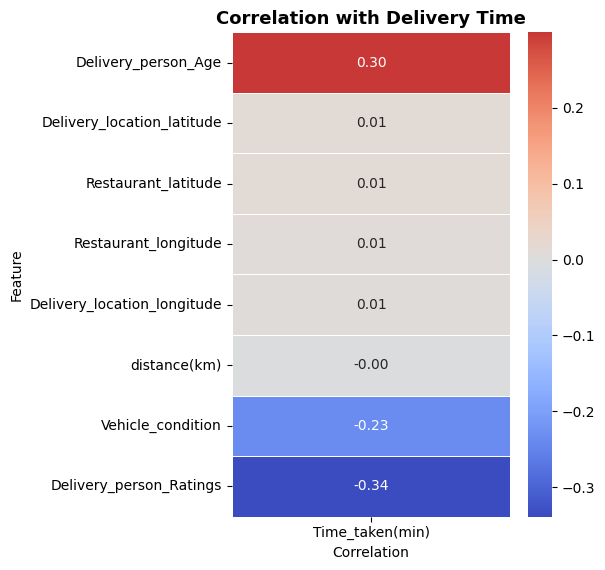

In [117]:
# 1️ Select numeric columns
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# 2️ Compute correlation matrix
corr_matrix = df[num_cols].corr()

# 3️ Only correlations with delivery time
corr_target = corr_matrix['Time_taken(min)'].drop('Time_taken(min)').sort_values(ascending=False)
print('Correlation with Delivery Time:')
print(corr_target.round(3))

# 4️ Plot simplified heatmap
plt.figure(figsize=(6, len(corr_target)*0.6 + 1))  # dynamic height based on number of features
sns.heatmap(corr_target.to_frame(), annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation with Delivery Time', fontsize=13, fontweight='bold')
plt.ylabel('Feature')
plt.xlabel('Correlation')
plt.tight_layout()
plt.savefig('outputs/correlation_target.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary — All Findings


In [109]:
print('=' * 60)
print('FOOD DELIVERY ANALYSIS — COMPLETE FINDINGS SUMMARY')
print('=' * 60)

# Problem 1 — Average delivery time
print(f'\nP1 | Avg delivery time   : {mean_t:.1f} mins | Std Dev: {std_t:.1f} mins')

# Problem 2 — Worst weather
if 'Weatherconditions' in df.columns:
    print(f'P2 | Worst weather       : {weather_stats.index[0]} ({weather_stats.iloc[0]["Avg_Time"]:.1f} mins avg)')
else:
    print('P2 | Worst weather       : N/A')

# Problem 3 — Rating correlation
print(f'P3 | Rating correlation  : {corr_rating:.3f} ({"higher rating = faster" if corr_rating < 0 else "higher rating = slower"})')

# Problem 4 — Outlier orders
print(f'P4 | Outlier orders      : {len(outliers)} ({len(outliers)/len(df)*100:.1f}% of all orders)')

# Problem 5 — Worst city
city_col = 'City' if 'City' in df.columns else None
if city_col:
    print(f'P5 | Worst city type     : {city_stats.index[0]} (avg {city_stats.iloc[0]["mean"]:.1f} mins)')
else:
    print('P5 | Worst city type     : N/A')

# Problem 6 — Partner age vs delivery speed
print(f'P6 | Age correlation     : {corr_age:.3f} | Fastest age group: {fastest_age}')

# Problem 7 — Vehicle type efficiency
print(f'P7 | Best vehicle overall: {vehicle_stats.index[0]} (avg {vehicle_stats.iloc[0]["Avg_Time"]:.1f} mins)')

print('\nAll 7 analyses complete. Charts saved in /outputs folder.')
print('=' * 60)

FOOD DELIVERY ANALYSIS — COMPLETE FINDINGS SUMMARY

P1 | Avg delivery time   : 26.3 mins | Std Dev: 9.4 mins
P2 | Worst weather       : conditions Cloudy (28.9 mins avg)
P3 | Rating correlation  : -0.339 (higher rating = faster)
P4 | Outlier orders      : 270 (0.6% of all orders)
P5 | Worst city type     : Semi-Urban (avg 49.7 mins)
P6 | Age correlation     : 0.299 | Fastest age group: 18-25
P7 | Best vehicle overall: electric_scooter (avg 24.5 mins)

All 7 analyses complete. Charts saved in /outputs folder.
